In [3]:
import sqlite3
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt

In [4]:
conn = sqlite3.connect(
    r'C:\Users\chaud\Machine Learning Project\Notebooks\inventory.db'
)

In [21]:
tables = pd.read_sql_query("SELECT name FROM sqlite_master WHERE type = 'table'",conn)
for table in tables['name']:
    print('Table name', table)
    df = pd.read_sql_query(f"select * from {table} limit 5",conn)
    display(df)


Table name purchases


,InventoryId,Store,Brand,Description,Size,VendorNumber,VendorName,PONumber,PODate,ReceivingDate,InvoiceDate,PayDate,PurchasePrice,Quantity,Dollars,Classification
0,69_MOUNTMEND_8412,69,8412,Tequila Ocho Plata Fresno,750mL,105,ALTAMAR BRANDS LLC,8124,2023-12-21,2024-01-02,2024-01-04,2024-02-16,35.71,6,214.26,1
1,30_CULCHETH_5255,30,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,4,37.40,1
2,34_PITMERDEN_5215,34,5215,TGI Fridays Long Island Iced,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-02,2024-01-07,2024-02-21,9.41,5,47.05,1
3,1_HARDERSFIELD_5255,1,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,6,56.10,1
4,76_DONCASTER_2034,76,2034,Glendalough Double Barrel,750mL,388,ATLANTIC IMPORTING COMPANY,8169,2023-12-24,2024-01-02,2024-01-09,2024-02-16,21.32,5,106.60,1


Table name purchase_prices


,Brand,Description,Price,Size,Volume,Classification,PurchasePrice,VendorNumber,VendorName
0,58,Gekkeikan Black & Gold Sake,12.99,750mL,750,1,9.28,8320,SHAW ROSS INT L IMP LTD
1,62,Herradura Silver Tequila,36.99,750mL,750,1,28.67,1128,BROWN-FORMAN CORP
2,63,Herradura Reposado Tequila,38.99,750mL,750,1,30.46,1128,BROWN-FORMAN CORP
3,72,No. 3 London Dry Gin,34.99,750mL,750,1,26.11,9165,ULTRA BEVERAGE COMPANY LLP
4,75,Three Olives Tomato Vodka,14.99,750mL,750,1,10.94,7245,PROXIMO SPIRITS INC.


Table name vendor_invoice


,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,None
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,None
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,None
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,None
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,None


Table name begin_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,startDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,8,12.99,2024-01-01
1,1_HARDERSFIELD_60,1,HARDERSFIELD,60,Canadian Club 1858 VAP,750mL,7,10.99,2024-01-01
2,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,6,36.99,2024-01-01
3,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,3,38.99,2024-01-01
4,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,6,34.99,2024-01-01


Table name end_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,endDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,11,12.99,2024-12-31
1,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,7,36.99,2024-12-31
2,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,7,38.99,2024-12-31
3,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,4,34.99,2024-12-31
4,1_HARDERSFIELD_75,1,HARDERSFIELD,75,Three Olives Tomato Vodka,750mL,7,14.99,2024-12-31


In [22]:
purchase_agg_df = query = """
SELECT
    p.PONumber,
    COUNT(DISTINCT p.Brand) AS total_brands,
    SUM(p.Quantity) AS total_item_quantity,
    SUM(p.Dollars) AS total_item_dollars,
    AVG(
        julianday(p.ReceivingDate) - julianday(p.PODate)
    ) AS avg_receiving_delay
FROM purchases p
GROUP BY p.PONumber
"""
purchase_summary = pd.read_sql_query(query, conn)

purchase_summary.head()

,PONumber,total_brands,total_item_quantity,total_item_dollars,avg_receiving_delay
0,8106,81,10100,137483.78,12.614130
1,8107,2,24,348.72,12.500000
2,8108,165,8466,60281.13,12.632479
3,8109,23,2246,14298.09,12.626866
4,8110,183,8086,56493.23,12.695271


In [23]:
vendor_df = pd.read_sql_query("""
SELECT
    vi.Quantity AS invoice_quantity,
    vi.Dollars AS invoice_dollars,
    vi.Freight AS invoice_freight,
    (julianday(vi.InvoiceDate) - julianday(vi.PODate)) AS days_po_to_invoice,
    (julianday(vi.PayDate) - julianday(vi.InvoiceDate)) AS days_invoice_to_pay
FROM vendor_invoice AS vi
""", conn)
vendor_df

,invoice_quantity,invoice_dollars,invoice_freight,days_po_to_invoice,days_invoice_to_pay
0,6,214.26,3.47,14.0,43.0
1,15,140.55,8.57,16.0,45.0
2,5,106.60,4.61,16.0,38.0
3,10100,137483.78,2935.20,23.0,24.0
4,1935,15527.25,429.20,14.0,36.0
...,...,...,...,...,...
5538,90,1563.00,8.60,16.0,35.0
5539,4617,37300.48,186.50,18.0,39.0
5540,9848,202815.78,932.95,11.0,33.0
5541,24747,149007.56,819.54,14.0,36.0


In [24]:
df = pd.read_sql_query("""
WITH purchase_agg AS (
    SELECT
        p.PONumber,
        COUNT(DISTINCT p.Brand) AS total_brands,
        SUM(p.Quantity) AS total_item_quantity,
        SUM(p.Dollars) AS total_item_dollars,
        AVG(
            julianday(p.ReceivingDate) - julianday(p.PODate)
        ) AS avg_receiving_delay
    FROM purchases p
    GROUP BY p.PONumber
)

SELECT
    vi.PONumber,
    vi.Quantity AS invoice_quantity,
    vi.Dollars AS invoice_dollars,
    vi.Freight,

    julianday(vi.InvoiceDate) - julianday(vi.PODate)
        AS days_po_to_invoice,

    julianday(vi.PayDate) - julianday(vi.InvoiceDate)
        AS days_to_pay,

    pa.total_brands,
    pa.total_item_quantity,
    pa.total_item_dollars,
    pa.avg_receiving_delay

FROM vendor_invoice vi

LEFT JOIN purchase_agg pa
    ON vi.PONumber = pa.PONumber

""", conn)

In [25]:
df

,PONumber,invoice_quantity,invoice_dollars,Freight,days_po_to_invoice,days_to_pay,total_brands,total_item_quantity,total_item_dollars,avg_receiving_delay
0,8124,6,214.26,3.47,14.0,43.0,1,6,214.26,12.000000
1,8137,15,140.55,8.57,16.0,45.0,2,15,140.55,10.333333
2,8169,5,106.60,4.61,16.0,38.0,1,5,106.60,9.000000
3,8106,10100,137483.78,2935.20,23.0,24.0,81,10100,137483.78,12.614130
4,8170,1935,15527.25,429.20,14.0,36.0,29,1935,15527.25,8.752809
...,...,...,...,...,...,...,...,...,...,...
5538,13626,90,1563.00,8.60,16.0,35.0,2,223,6823.18,5.871795
5539,13661,4617,37300.48,186.50,18.0,39.0,110,24747,149007.56,5.050500
5540,13643,9848,202815.78,932.95,11.0,33.0,5,180,2559.72,5.000000
5541,13602,24747,149007.56,819.54,14.0,36.0,83,43240,318075.65,8.045541


In [26]:
df.isnull().sum()

PONumber               0
invoice_quantity       0
invoice_dollars        0
Freight                0
days_po_to_invoice     0
days_to_pay            0
total_brands           0
total_item_quantity    0
total_item_dollars     0
avg_receiving_delay    0
dtype: int64

In [27]:
df.dtypes

PONumber                 int64
invoice_quantity         int64
invoice_dollars        float64
Freight                float64
days_po_to_invoice     float64
days_to_pay            float64
total_brands             int64
total_item_quantity      int64
total_item_dollars     float64
avg_receiving_delay    float64
dtype: object

In [34]:
def create_invoice_risk_label(row):

    # Invoice total mismatch with item-level total
    if abs(row["invoice_dollars"] - row["total_item_dollars"]) > 5:
        return 1

    # Abnormally high receiving delay
    if row["avg_receiving_delay"] > 10:
        return 1

    return 0


# Create invoice risk flag
df["flag_invoice"] = df.apply(create_invoice_risk_label, axis=1)

# Count risky and non-risky invoices
df["flag_invoice"].value_counts()

    

flag_invoice
0    3693
1    1850
Name: count, dtype: int64

<Axes: xlabel='flag_invoice'>

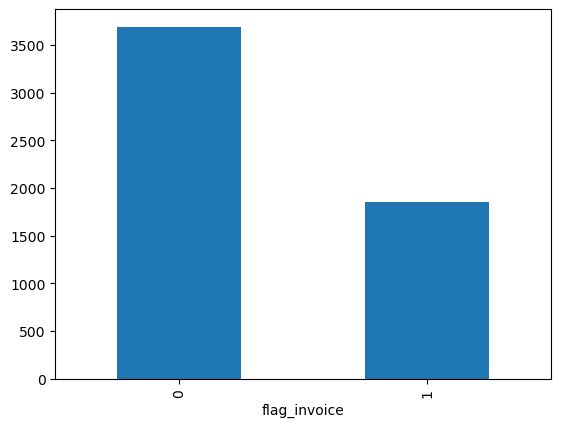

In [35]:
df["flag_invoice"].value_counts().plot(kind = "bar")

In [36]:
df.corr()

,PONumber,invoice_quantity,invoice_dollars,Freight,days_po_to_invoice,days_to_pay,total_brands,total_item_quantity,total_item_dollars,avg_receiving_delay,flag_invoice
PONumber,1.000000,0.049230,0.058917,0.043617,-0.002234,0.012558,0.013423,0.049442,0.059221,-0.042362,0.564946
invoice_quantity,0.049230,1.000000,0.963831,0.946550,0.000526,0.022284,0.566394,0.706117,0.668171,0.000519,0.032783
invoice_dollars,0.058917,0.963831,1.000000,0.985141,0.001610,0.025661,0.536952,0.667666,0.679537,0.004694,0.037994
Freight,0.043617,0.946550,0.985141,1.000000,0.003265,0.025513,0.536381,0.656616,0.670768,0.015645,0.037759
days_po_to_invoice,-0.002234,0.000526,0.001610,0.003265,1.000000,-0.370432,0.009519,0.005543,0.007931,0.515538,0.183115
days_to_pay,0.012558,0.022284,0.025661,0.025513,-0.370432,1.000000,0.020336,0.016203,0.015610,-0.029403,-0.005289
total_brands,0.013423,0.566394,0.536952,0.536381,0.009519,0.020336,1.000000,0.783825,0.753092,0.000496,0.008961
total_item_quantity,0.049442,0.706117,0.667666,0.656616,0.005543,0.016203,0.783825,1.000000,0.963831,-0.014016,0.032783
total_item_dollars,0.059221,0.668171,0.679537,0.670768,0.007931,0.015610,0.753092,0.963831,1.000000,-0.014251,0.037994
avg_receiving_delay,-0.042362,0.000519,0.004694,0.015645,0.515538,-0.029403,0.000496,-0.014016,-0.014251,1.000000,0.311667


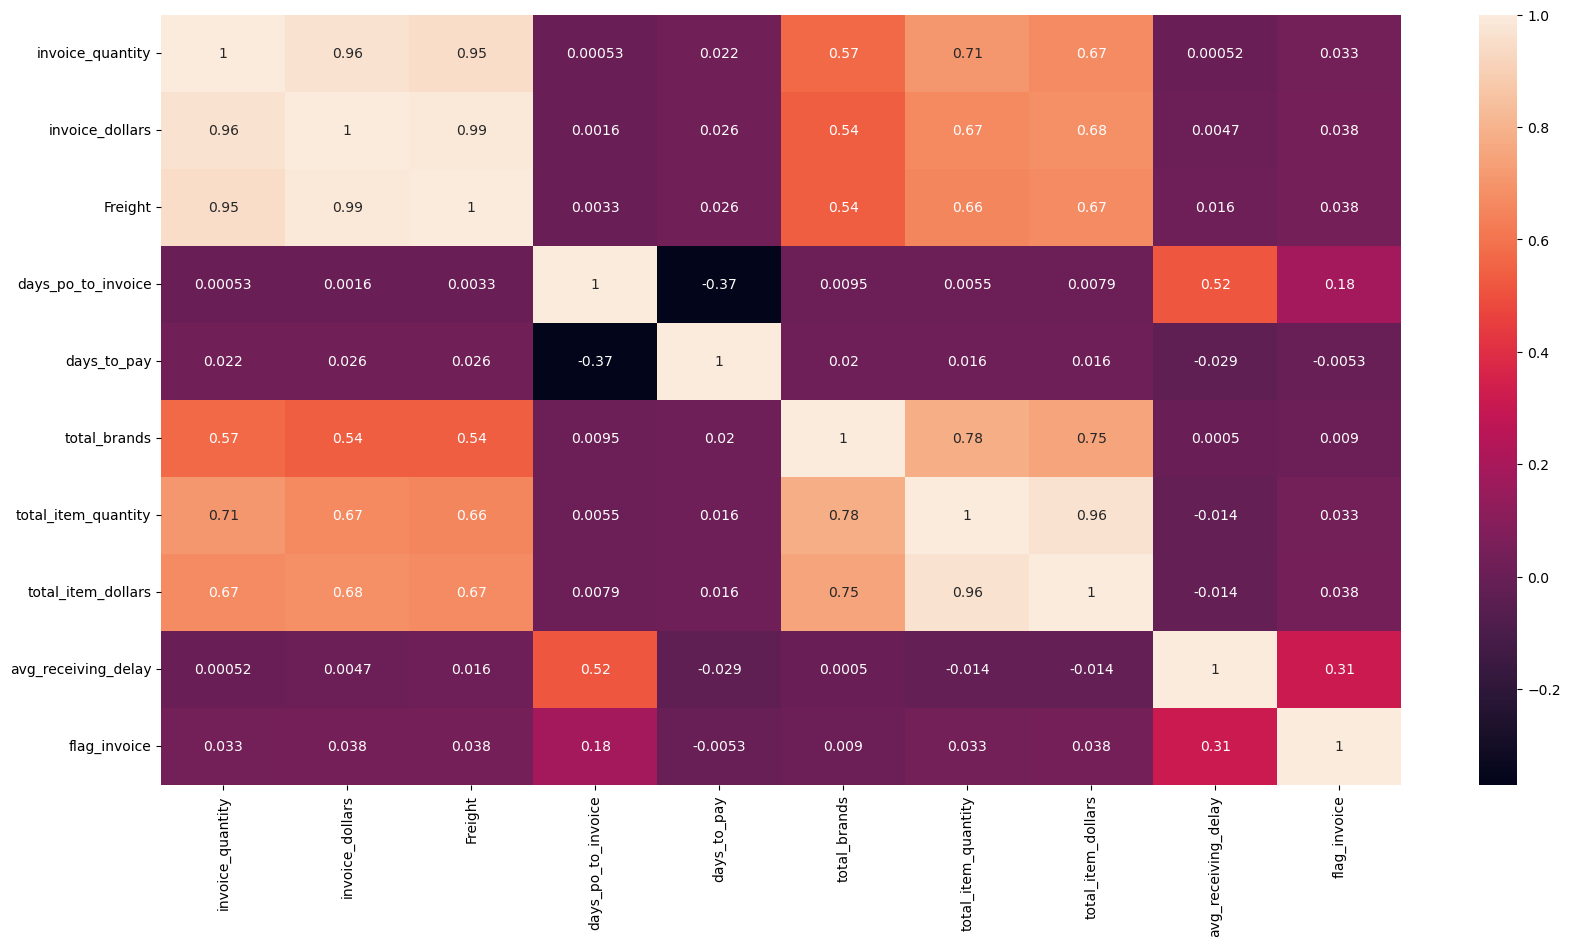

In [37]:
plt.figure(figsize=(20,10))
sns.heatmap(df.iloc[:,1:].corr(),annot =True)
plt.show()

In [38]:
flagged = df[df['flag_invoice']==1]
normal = df[df['flag_invoice']==0]

In [39]:
signficant_feature = []
non_significant_features =[]
results = []

In [40]:
metrics= ['invoice_quantity', 'invoice_dollars', 'Freight',
          'days_po_to_invoice', 'days_to_pay', 'total_brands',
          'total_item_quantity', 'total_item_dollars', 'avg_receiving_delay']

In [41]:
from scipy.stats import ttest_ind

significant_features = []
non_significant_features = []
results = []

for metric in metrics:

    flagged_mean = flagged[metric].mean()
    normal_mean = normal[metric].mean()

    t_stat, p_value = ttest_ind(
        flagged[metric].dropna(),
        normal[metric].dropna(),
        equal_var=False
    )

    if p_value < 0.05:
        significant_features.append(metric)

        results.append({
            "metric": metric,
            "flagged_mean": round(flagged_mean, 2),
            "normal_mean": round(normal_mean, 2),
            "p_value": round(p_value, 3)
        })

    else:
        non_significant_features.append(metric)

# Convert results to DataFrame
results_df = pd.DataFrame(results)

print(results_df)

                metric  flagged_mean  normal_mean  p_value
0     invoice_quantity       6728.28      5723.55    0.021
1      invoice_dollars      65600.61     54302.64    0.008
2              Freight        334.02       276.89    0.008
3   days_po_to_invoice         17.23        16.02    0.000
4  total_item_quantity       6728.28      5723.55    0.021
5   total_item_dollars      65600.61     54302.64    0.008
6  avg_receiving_delay          8.47         7.27    0.000


In [42]:
from scipy.stats import ttest_ind

significant_features = []
non_significant_features = []
results = []

for metric in metrics:

    flagged_mean = flagged[metric].mean()
    normal_mean = normal[metric].mean()

    t_stat, p_value = ttest_ind(
        flagged[metric].dropna(),
        normal[metric].dropna(),
        equal_var=False
    )

    if p_value < 0.05:
        significant_features.append(metric)

        results.append({
            "metric": metric,
            "flagged_mean": round(flagged_mean, 2),
            "normal_mean": round(normal_mean, 2),
            "p_value": round(p_value, 3)
        })

    else:
        non_significant_features.append(metric)

# Convert results to DataFrame
results_df = pd.DataFrame(results)

print(results_df)

                metric  flagged_mean  normal_mean  p_value
0     invoice_quantity       6728.28      5723.55    0.021
1      invoice_dollars      65600.61     54302.64    0.008
2              Freight        334.02       276.89    0.008
3   days_po_to_invoice         17.23        16.02    0.000
4  total_item_quantity       6728.28      5723.55    0.021
5   total_item_dollars      65600.61     54302.64    0.008
6  avg_receiving_delay          8.47         7.27    0.000


In [43]:
X = df[
    [
        'invoice_quantity',
        'invoice_dollars',
        'Freight',
        'total_brands',
        'total_item_quantity',
        'days_po_to_invoice',
        'total_item_dollars'
    ]
]

Y = df['flag_invoice']

In [44]:
X

,invoice_quantity,invoice_dollars,Freight,total_brands,total_item_quantity,days_po_to_invoice,total_item_dollars
0,6,214.26,3.47,1,6,14.0,214.26
1,15,140.55,8.57,2,15,16.0,140.55
2,5,106.60,4.61,1,5,16.0,106.60
3,10100,137483.78,2935.20,81,10100,23.0,137483.78
4,1935,15527.25,429.20,29,1935,14.0,15527.25
...,...,...,...,...,...,...,...
5538,90,1563.00,8.60,2,223,16.0,6823.18
5539,4617,37300.48,186.50,110,24747,18.0,149007.56
5540,9848,202815.78,932.95,5,180,11.0,2559.72
5541,24747,149007.56,819.54,83,43240,14.0,318075.65


In [45]:
y

NameError: name 'y' is not defined

In [46]:
X.describe().round()

,invoice_quantity,invoice_dollars,Freight,total_brands,total_item_quantity,days_po_to_invoice,total_item_dollars
count,5543.0,5543.0,5543.0,5543.0,5543.0,5543.0,5543.0
mean,6059.0,58073.0,296.0,41.0,6059.0,16.0,58073.0
std,14453.0,140234.0,714.0,77.0,14453.0,3.0,140234.0
min,1.0,4.0,0.0,1.0,1.0,9.0,4.0
25%,83.0,968.0,5.0,3.0,83.0,14.0,968.0
50%,423.0,4765.0,25.0,7.0,423.0,16.0,4765.0
75%,5100.0,44587.0,230.0,46.0,5100.0,19.0,44587.0
max,141660.0,1660436.0,8468.0,807.0,141660.0,23.0,1660436.0


In [47]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

NameError: name 'X_train' is not defined

In [48]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [49]:
# Logistic Regression
model1 = LogisticRegression(random_state=42)
model1.fit(X_train_scaled, y_train)

# Decision Tree
model2 = DecisionTreeClassifier(random_state=42)
model2.fit(X_train_scaled, y_train)

# Random Forest
model3 = RandomForestClassifier(random_state=42)
model3.fit(X_train_scaled, y_train)

NameError: name 'X_train_scaled' is not defined

In [50]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

NameError: name 'y' is not defined

In [51]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

NameError: name 'X_train' is not defined

In [52]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

model1 = LogisticRegression(random_state=42)
model1.fit(X_train_scaled, y_train)

model2 = DecisionTreeClassifier(random_state=42)
model2.fit(X_train, y_train)

model3 = RandomForestClassifier(random_state=42)
model3.fit(X_train, y_train)

NameError: name 'X_train_scaled' is not defined

In [53]:
evaluate_model(
    model1,
    X_test_scaled,
    y_test,
    "Logistic Regression"
)

evaluate_model(
    model2,
    X_test,
    y_test,
    "Decision Tree Classifier"
)

evaluate_model(
    model3,
    X_test,
    y_test,
    "Random Forest Classifier"
)

NameError: name 'evaluate_model' is not defined

In [54]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

def evaluate_model(model, X_test, y_test, model_name):

    preds = model.predict(X_test)

    accuracy = accuracy_score(y_test, preds)
    precision = precision_score(y_test, preds, zero_division=0)
    recall = recall_score(y_test, preds, zero_division=0)
    f1 = f1_score(y_test, preds, zero_division=0)

    print(f"\n{model_name} Performance:")
    print(f"Accuracy:  {accuracy:.2f}")
    print(f"Precision: {precision:.2f}")
    print(f"Recall:    {recall:.2f}")
    print(f"F1 Score:  {f1:.2f}")

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, preds))

In [55]:
evaluate_model(
    model1,
    X_test_scaled,
    y_test,
    "Logistic Regression"
)

evaluate_model(
    model2,
    X_test,
    y_test,
    "Decision Tree Classifier"
)

evaluate_model(
    model3,
    X_test,
    y_test,
    "Random Forest Classifier"
)

NameError: name 'X_test_scaled' is not defined

In [56]:
evaluate_model(
    model1,
    X_test_scaled,
    y_test,
    "Logistic Regression"
)

evaluate_model(
    model2,
    X_test_scaled,
    y_test,
    "Decision Tree Classifier"
)

evaluate_model(
    model3,
    X_test_scaled,
    y_test,
    "Random Forest Classifier"
)

NameError: name 'X_test_scaled' is not defined

In [57]:
model3.feature_importances_

NameError: name 'model3' is not defined

In [58]:
feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": model3.feature_importances_
}).sort_values(by="importance",ascending=False)

feature_importance

NameError: name 'X_train' is not defined

In [59]:
X = df[
    [
        'invoice_quantity',
        'invoice_dollars',
        'Freight',
        'total_item_quantity',
        'total_item_dollars'
    ]
]

Y = df['flag_invoice']

In [60]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Create scaler
scaler = StandardScaler()

# Scale training data
X_train_scaled = scaler.fit_transform(X_train)

# Scale test data
X_test_scaled = scaler.transform(X_test)

NameError: name 'y' is not defined

In [61]:

model3 = RandomForestClassifier(random_state=42)
model3.fit(X_train, y_train)

evaluate_model(
    model3,
    X_test,
    y_test,
    "Random Forest Classifier"
)

NameError: name 'X_train' is not defined

In [62]:
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 4, 5, 6],
    "min_samples_split": [2, 3, 5],
    "min_samples_leaf":[1, 2, 5],
    "criterion":['gini','entropy']
}               

In [63]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import make_scorer, f1_score
from sklearn.model_selection import GridSearchCV

# Random Forest model
rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

# Parameter grid
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 4, 5, 6],
    "min_samples_split": [2, 3, 5],
    "min_samples_leaf": [1, 2, 5],
    "criterion": ["gini", "entropy"]
}

# F1 scorer
scorer = make_scorer(f1_score)

# Grid Search
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring=scorer,
    cv=5,
    verbose=2,
    n_jobs=-1
)

# Train GridSearch
grid_search.fit(X_train_scaled, y_train)

# Best parameters
print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest F1 Score:")
print(grid_search.best_score_)

# Evaluate best model
evaluate_model(
    grid_search,
    X_test_scaled,
    y_test,
    "Random Forest Classifier"
)

NameError: name 'X_train_scaled' is not defined

In [64]:
from sklearn.metrics import confusion_matrix

In [65]:
confusion_matricx(grid_search.predict(X_test_scaled), y_test)

NameError: name 'confusion_matricx' is not defined

In [66]:
confusion_matrix(model3.predect(X_text_scaled), y_text)

AttributeError: 'RandomForestClassifier' object has no attribute 'predect'

In [67]:
from sklearn.metrics import confusion_matrix
predictions = model3.predict(X_test_scaled)
cm = confusion_matrix(y_test, predictions)
print(cm)

NameError: name 'X_test_scaled' is not defined

In [68]:
from sklearn.metrics import confusion_matrix

predictions = grid_search.predict(X_test_scaled)

cm = confusion_matrix(y_test, predictions)

print(cm)

NameError: name 'X_test_scaled' is not defined

In [69]:
grid_search.best_params_

AttributeError: 'GridSearchCV' object has no attribute 'best_params_'

In [70]:
X = df[
    [
        'invoice_quantity',
        'invoice_dollars',
        'Freight',
        'total_item_quantity',
        'total_item_dollars'
    ]
]

y = df['flag_invoice']

In [71]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [72]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [73]:
print(X_train_scaled.shape)
print(X_test_scaled.shape)

(4434, 5)
(1109, 5)


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import make_scorer, f1_score
from sklearn.model_selection import GridSearchCV

rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 4, 5, 6],
    "min_samples_split": [2, 3, 5],
    "min_samples_leaf": [1, 2, 5],
    "criterion": ["gini", "entropy"]
}

scorer = make_scorer(f1_score)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring=scorer,
    cv=5,
    verbose=2,
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("Best F1 Score:")
print(grid_search.best_score_)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits


In [ ]:
confusion_matricx